In [ ]:
import simpy
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import itertools

DURACION_SIM = 5 * 24 * 60

In [28]:
SEMILLA = 42
random.seed(SEMILLA)
np.random.seed(SEMILLA)

In [29]:
def obtener_tiempo(minutos):
    minutos = int(minutos)
    return f"Día {minutos//(60*24) + 1} - {(minutos//60)%24:02d}:{minutos%60:02d}"

def calcular_defecto(t_minutos):
    return 1 / (1 + math.exp((t_minutos - 40) / 13))


class Fabrica:
    def __init__(self, env, robots_rotor=2, robots_estator=2, operarios_rotor=2,
                 operarios_estator=2, cap_stock=500, lote_reposicion=200,
                 lineas_ensamblado=3, punto_critico=250, tiempo_entrega=8*60):
        self.env             = env
        self.punto_critico   = punto_critico
        self.lote_reposicion = lote_reposicion
        self.tiempo_entrega  = tiempo_entrega

        self.stock_cobre    = simpy.Container(env, capacity=cap_stock, init=cap_stock)
        self.stock_aluminio = simpy.Container(env, capacity=cap_stock, init=cap_stock)
        self.pedido_cobre_en_camino    = False
        self.pedido_aluminio_en_camino = False

        self.robots_rotor      = simpy.Resource(env, capacity=robots_rotor)
        self.robots_estator    = simpy.Resource(env, capacity=robots_estator)
        self.operarios_rotor   = simpy.Resource(env, capacity=operarios_rotor)
        self.operarios_estator = simpy.Resource(env, capacity=operarios_estator)
        self.lineas_ensamblado = simpy.Resource(env, capacity=lineas_ensamblado)

        self.rotores_ok      = simpy.Store(env)
        self.estatores_ok    = simpy.Store(env)
        self.almacen_motores = simpy.Store(env, capacity=20)

        self.tiempos_espera_stock  = []
        self.motores_producidos    = 0
        self.rotores_totales       = 0
        self.rotores_defectuosos   = 0
        self.estatores_totales     = 0
        self.estatores_defectuosos = 0


def pedir_material(env, fabrica, tipo_material):
    yield env.timeout(fabrica.tiempo_entrega)
    if tipo_material == "Cobre":
        espacio = fabrica.stock_cobre.capacity - fabrica.stock_cobre.level
        yield fabrica.stock_cobre.put(min(fabrica.lote_reposicion, espacio))
        fabrica.pedido_cobre_en_camino = False
    else:
        espacio = fabrica.stock_aluminio.capacity - fabrica.stock_aluminio.level
        yield fabrica.stock_aluminio.put(min(fabrica.lote_reposicion, espacio))
        fabrica.pedido_aluminio_en_camino = False


def control_stock(env, fabrica):
    while True:
        if fabrica.stock_cobre.level <= fabrica.punto_critico and not fabrica.pedido_cobre_en_camino:
            fabrica.pedido_cobre_en_camino = True
            env.process(pedir_material(env, fabrica, "Cobre"))
        if fabrica.stock_aluminio.level <= fabrica.punto_critico and not fabrica.pedido_aluminio_en_camino:
            fabrica.pedido_aluminio_en_camino = True
            env.process(pedir_material(env, fabrica, "Aluminio"))
        yield env.timeout(1)


def linea_rotor(env, fabrica, id_pieza):
    with fabrica.robots_rotor.request() as req:
        yield req
        t0 = env.now
        yield fabrica.stock_cobre.get(8)
        yield fabrica.stock_aluminio.get(8)
        espera = env.now - t0
        if espera > 0:
            fabrica.tiempos_espera_stock.append(espera)
        t_fab = max(0.5, random.gauss(1, 0.5)) * 60
        yield env.timeout(t_fab)

    with fabrica.operarios_rotor.request() as req:
        yield req
        yield env.timeout(max(0.5, random.gauss(2, 0.5)) * 60)
        fabrica.rotores_totales += 1
        if random.random() >= calcular_defecto(t_fab):
            yield fabrica.rotores_ok.put(1)
        else:
            fabrica.rotores_defectuosos += 1


def linea_estator(env, fabrica, id_pieza):
    with fabrica.robots_estator.request() as req:
        yield req
        t0 = env.now
        yield fabrica.stock_cobre.get(8)
        yield fabrica.stock_aluminio.get(8)
        espera = env.now - t0
        if espera > 0:
            fabrica.tiempos_espera_stock.append(espera)
        t_fab = max(0.5, random.gauss(2, 0.5)) * 60
        yield env.timeout(t_fab)

    with fabrica.operarios_estator.request() as req:
        yield req
        yield env.timeout(max(0.5, random.gauss(1, 0.5)) * 60)
        fabrica.estatores_totales += 1
        if random.random() >= calcular_defecto(t_fab):
            yield fabrica.estatores_ok.put(1)
        else:
            fabrica.estatores_defectuosos += 1


def ensamblar_motor(env, fabrica, id_motor):
    with fabrica.lineas_ensamblado.request() as req:
        yield req
        yield env.timeout(max(0.5, random.gauss(2, 1)) * 60)
        yield fabrica.almacen_motores.put(1)
        if len(fabrica.almacen_motores.items) == 20:
            fabrica.motores_producidos += 20
            for _ in range(20):
                yield fabrica.almacen_motores.get()


def generador_rotores(env, fabrica):
    i = 1
    while True:
        env.process(linea_rotor(env, fabrica, i))
        yield env.timeout(1)
        i += 1

def generador_estatores(env, fabrica):
    i = 1
    while True:
        env.process(linea_estator(env, fabrica, i))
        yield env.timeout(1)
        i += 1

def generador_ensamblado(env, fabrica):
    i = 1
    while True:
        yield fabrica.rotores_ok.get()
        yield fabrica.estatores_ok.get()
        env.process(ensamblar_motor(env, fabrica, i))
        i += 1


def lanzar_fabrica(env, fabrica):
    env.process(control_stock(env, fabrica))
    env.process(generador_rotores(env, fabrica))
    env.process(generador_estatores(env, fabrica))
    env.process(generador_ensamblado(env, fabrica))


def ejecutar_simulacion(seed=None, **kwargs):
    if seed is not None:
        random.seed(seed)
    env     = simpy.Environment()
    fabrica = Fabrica(env, **kwargs)
    lanzar_fabrica(env, fabrica)
    env.run(until=DURACION_SIM)

    total_motores = fabrica.motores_producidos + len(fabrica.almacen_motores.items)
    espera_media  = np.mean(fabrica.tiempos_espera_stock) if fabrica.tiempos_espera_stock else 0.0

    return {
        "motores":      total_motores,
        "espera":       espera_media,
        "pct_rot_def":  (fabrica.rotores_defectuosos  / fabrica.rotores_totales  * 100
                         if fabrica.rotores_totales  > 0 else 0.0),
        "pct_est_def":  (fabrica.estatores_defectuosos / fabrica.estatores_totales * 100
                         if fabrica.estatores_totales > 0 else 0.0),
    }

print("Modelo cargado.")

Modelo cargado.


In [ ]:

random.seed(42)
env     = simpy.Environment()
fabrica = Fabrica(env, punto_critico=100)

def pedir_material_print(env, fabrica, tipo_material):
    print(f"[{obtener_tiempo(env.now)}] SOLICITUD DE RECARGA: {tipo_material}")
    yield env.timeout(fabrica.tiempo_entrega)
    if tipo_material == "Cobre":
        espacio = fabrica.stock_cobre.capacity - fabrica.stock_cobre.level
        yield fabrica.stock_cobre.put(min(fabrica.lote_reposicion, espacio))
        fabrica.pedido_cobre_en_camino = False
    else:
        espacio = fabrica.stock_aluminio.capacity - fabrica.stock_aluminio.level
        yield fabrica.stock_aluminio.put(min(fabrica.lote_reposicion, espacio))
        fabrica.pedido_aluminio_en_camino = False
    print(f"[{obtener_tiempo(env.now)}] RECARGA COMPLETADA: {fabrica.lote_reposicion} de {tipo_material}")

def control_stock_print(env, fabrica):
    while True:
        if fabrica.stock_cobre.level <= fabrica.punto_critico and not fabrica.pedido_cobre_en_camino:
            fabrica.pedido_cobre_en_camino = True
            env.process(pedir_material_print(env, fabrica, "Cobre"))
        if fabrica.stock_aluminio.level <= fabrica.punto_critico and not fabrica.pedido_aluminio_en_camino:
            fabrica.pedido_aluminio_en_camino = True
            env.process(pedir_material_print(env, fabrica, "Aluminio"))
        yield env.timeout(1)

def linea_rotor_print(env, fabrica, id_pieza):
    with fabrica.robots_rotor.request() as req:
        yield req
        t0 = env.now
        yield fabrica.stock_cobre.get(8)
        yield fabrica.stock_aluminio.get(8)
        espera = env.now - t0
        if espera > 0:
            print(f"[{obtener_tiempo(env.now)}] MAQUINA ROTOR ESPERO {espera:.1f} min por material.")
            fabrica.tiempos_espera_stock.append(espera)
        t_fab = max(0.5, random.gauss(1, 0.5)) * 60
        yield env.timeout(t_fab)

    with fabrica.operarios_rotor.request() as req:
        yield req
        yield env.timeout(max(0.5, random.gauss(2, 0.5)) * 60)
        fabrica.rotores_totales += 1
        prob_defecto = calcular_defecto(t_fab)
        if random.random() >= prob_defecto:
            print(f"[{obtener_tiempo(env.now)}] ROTOR {id_pieza} LISTO para ensamblado.")
            yield fabrica.rotores_ok.put(1)
        else:
            fabrica.rotores_defectuosos += 1
            print(f"[{obtener_tiempo(env.now)}] ROTOR {id_pieza} DESCARTADO (Fabricado en {t_fab:.1f}m, Prob: {prob_defecto:.2f})")

def linea_estator_print(env, fabrica, id_pieza):
    with fabrica.robots_estator.request() as req:
        yield req
        t0 = env.now
        yield fabrica.stock_cobre.get(8)
        yield fabrica.stock_aluminio.get(8)
        espera = env.now - t0
        if espera > 0:
            print(f"[{obtener_tiempo(env.now)}] MAQUINA ESTATOR ESPERO {espera:.1f} min por material.")
            fabrica.tiempos_espera_stock.append(espera)
        t_fab = max(0.5, random.gauss(2, 0.5)) * 60
        yield env.timeout(t_fab)

    with fabrica.operarios_estator.request() as req:
        yield req
        yield env.timeout(max(0.5, random.gauss(1, 0.5)) * 60)
        fabrica.estatores_totales += 1
        prob_defecto = calcular_defecto(t_fab)
        if random.random() >= prob_defecto:
            print(f"[{obtener_tiempo(env.now)}] ESTATOR {id_pieza} LISTO para ensamblado.")
            yield fabrica.estatores_ok.put(1)
        else:
            fabrica.estatores_defectuosos += 1
            print(f"[{obtener_tiempo(env.now)}] ESTATOR {id_pieza} DESCARTADO (Fabricado en {t_fab:.1f}m, Prob: {prob_defecto:.2f})")

def ensamblar_motor_print(env, fabrica, id_motor):
    with fabrica.lineas_ensamblado.request() as req:
        yield req
        yield env.timeout(max(0.5, random.gauss(2, 1)) * 60)
        print(f"[{obtener_tiempo(env.now)}] MOTOR {id_motor} ENSAMBLADO. Almacenando...")
        yield fabrica.almacen_motores.put(1)
        if len(fabrica.almacen_motores.items) == 20:
            print(f"\n[{obtener_tiempo(env.now)}] ENVIANDO LOTE DE 20 MOTORES...\n")
            fabrica.motores_producidos += 20
            for _ in range(20):
                yield fabrica.almacen_motores.get()

def generador_rotores_print(env, fabrica):
    i = 1
    while True:
        env.process(linea_rotor_print(env, fabrica, i))
        yield env.timeout(1)
        i += 1

def generador_estatores_print(env, fabrica):
    i = 1
    while True:
        env.process(linea_estator_print(env, fabrica, i))
        yield env.timeout(1)
        i += 1

def generador_ensamblado_print(env, fabrica):
    i = 1
    while True:
        yield fabrica.rotores_ok.get()
        yield fabrica.estatores_ok.get()
        env.process(ensamblar_motor_print(env, fabrica, i))
        i += 1

print("INICIANDO SIMULACION - PUNTO CRITICO: 100")
print("-" * 50)

env.process(control_stock_print(env, fabrica))
env.process(generador_rotores_print(env, fabrica))
env.process(generador_estatores_print(env, fabrica))
env.process(generador_ensamblado_print(env, fabrica))
env.run(until=DURACION_SIM)

print("-" * 50)
print("RESULTADOS DE LA SIMULACION (5 DIAS):")
espera_media = np.mean(fabrica.tiempos_espera_stock) if fabrica.tiempos_espera_stock else 0
print(f"Tiempo medio de espera por stock: {espera_media:.2f} minutos")
total_motores = fabrica.motores_producidos + len(fabrica.almacen_motores.items)
print(f"Total motores producidos: {total_motores}")
if fabrica.rotores_totales > 0:
    print(f"Rotores fabricados: {fabrica.rotores_totales} | Defectuosos: {fabrica.rotores_defectuosos/fabrica.rotores_totales*100:.2f}%")
if fabrica.estatores_totales > 0:
    print(f"Estatores fabricados: {fabrica.estatores_totales} | Defectuosos: {fabrica.estatores_defectuosos/fabrica.estatores_totales*100:.2f}%")

INICIANDO SIMULACION - PUNTO CRITICO: 100
--------------------------------------------------
[Día 1 - 02:51] ROTOR 1 DESCARTADO (Fabricado en 55.7m, Prob: 0.23)
[Día 1 - 03:01] ESTATOR 1 LISTO para ensamblado.
[Día 1 - 03:07] ROTOR 2 LISTO para ensamblado.
[Día 1 - 03:25] ESTATOR 2 LISTO para ensamblado.
[Día 1 - 04:21] ROTOR 3 LISTO para ensamblado.
[Día 1 - 04:38] ROTOR 4 LISTO para ensamblado.
[Día 1 - 04:50] MOTOR 1 ENSAMBLADO. Almacenando...
[Día 1 - 05:11] ESTATOR 4 LISTO para ensamblado.
[Día 1 - 05:15] MOTOR 2 ENSAMBLADO. Almacenando...
[Día 1 - 05:24] ESTATOR 3 LISTO para ensamblado.
[Día 1 - 05:38] ROTOR 5 LISTO para ensamblado.
[Día 1 - 05:58] MOTOR 3 ENSAMBLADO. Almacenando...
[Día 1 - 06:11] ROTOR 6 LISTO para ensamblado.
[Día 1 - 06:49] ESTATOR 6 LISTO para ensamblado.
[Día 1 - 07:08] ESTATOR 5 LISTO para ensamblado.
[Día 1 - 07:50] MOTOR 4 ENSAMBLADO. Almacenando...
[Día 1 - 07:52] ROTOR 7 LISTO para ensamblado.
[Día 1 - 07:58] ROTOR 8 DESCARTADO (Fabricado en 30.0m, Pro

In [ ]:
N_REPLICAS = 100
puntos_criticos = list(range(50, 401,10))
resultados_espera = []

for idx, pc in enumerate(puntos_criticos, 1):
    replicas = [ejecutar_simulacion(seed=i, punto_critico=pc) for i in range(N_REPLICAS)]
    espera_media = np.mean([r["espera"] for r in replicas])
    resultados_espera.append(espera_media)
    print(f"[{idx}/{len(puntos_criticos)}] PC={pc} | Espera={espera_media:.2f} min")

df_pc = pd.DataFrame({"Punto_Critico": puntos_criticos, "Espera_Media_Minutos": resultados_espera})
df_pc.to_csv("Datos/Transformados/SIMULACION/resultados_stock.csv", index=False)

[1/36] PC=50 | Espera=319.99 min
[2/36] PC=60 | Espera=278.18 min
[3/36] PC=70 | Espera=257.79 min
[4/36] PC=80 | Espera=235.71 min
[5/36] PC=90 | Espera=216.67 min
[6/36] PC=100 | Espera=175.74 min
[7/36] PC=110 | Espera=156.35 min
[8/36] PC=120 | Espera=132.39 min
[9/36] PC=130 | Espera=112.63 min
[10/36] PC=140 | Espera=82.80 min
[11/36] PC=150 | Espera=69.53 min
[12/36] PC=160 | Espera=54.24 min
[13/36] PC=170 | Espera=42.30 min
[14/36] PC=180 | Espera=27.30 min
[15/36] PC=190 | Espera=22.40 min
[16/36] PC=200 | Espera=16.92 min
[17/36] PC=210 | Espera=10.34 min
[18/36] PC=220 | Espera=2.52 min
[19/36] PC=230 | Espera=0.97 min
[20/36] PC=240 | Espera=0.45 min
[21/36] PC=250 | Espera=0.37 min
[22/36] PC=260 | Espera=0.00 min
[23/36] PC=270 | Espera=0.00 min
[24/36] PC=280 | Espera=0.00 min
[25/36] PC=290 | Espera=0.00 min
[26/36] PC=300 | Espera=0.00 min
[27/36] PC=310 | Espera=0.00 min
[28/36] PC=320 | Espera=0.00 min
[29/36] PC=330 | Espera=0.00 min
[30/36] PC=340 | Espera=0.00 mi

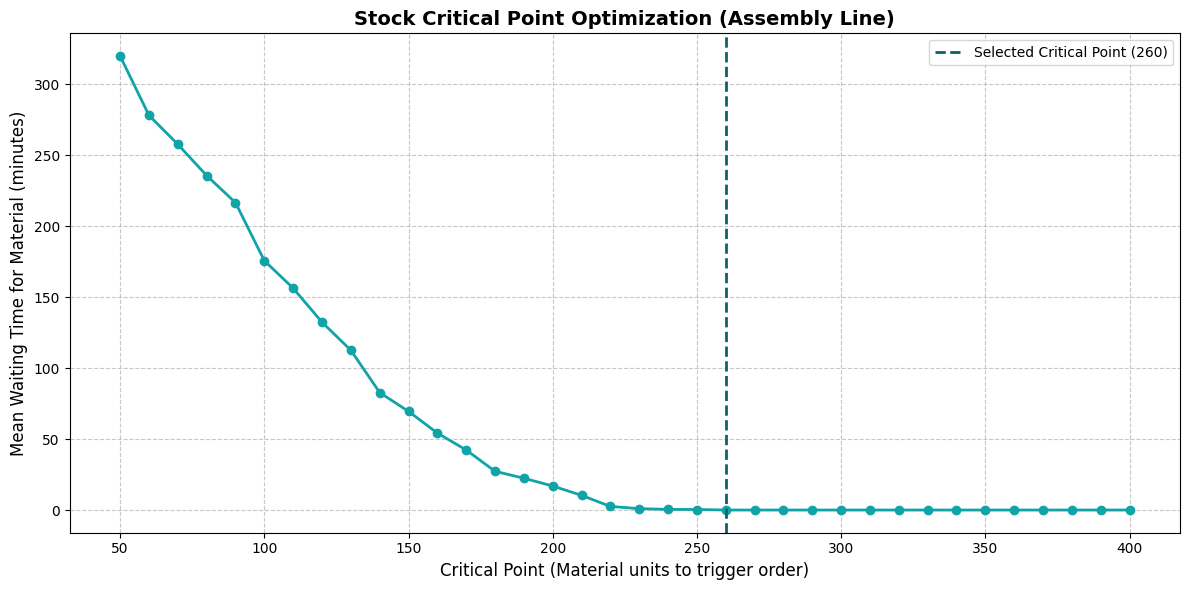

In [ ]:
resultados = pd.read_csv('Datos/Transformados/SIMULACION/resultados_stock.csv')

plt.figure(figsize=(12,6))
plt.plot(resultados['Punto_Critico'], resultados['Espera_Media_Minutos'], marker='o', linestyle='-', color='#10a3a7', linewidth=2)


plt.axvline(x=260, color='#0d626a', linestyle='--', linewidth=2, label='Selected Critical Point (260)')

plt.title('Stock Critical Point Optimization (Assembly Line)', fontsize=14, fontweight='bold')
plt.xlabel('Critical Point (Material units to trigger order)', fontsize=12)
plt.ylabel('Mean Waiting Time for Material (minutes)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend() 
plt.tight_layout()
plt.show()

In [ ]:

random.seed(42)
env     = simpy.Environment()
fabrica = Fabrica(env, punto_critico=260)

def pedir_material_print(env, fabrica, tipo_material):
    print(f"[{obtener_tiempo(env.now)}] SOLICITUD DE RECARGA: {tipo_material}")
    yield env.timeout(fabrica.tiempo_entrega)
    if tipo_material == "Cobre":
        espacio = fabrica.stock_cobre.capacity - fabrica.stock_cobre.level
        yield fabrica.stock_cobre.put(min(fabrica.lote_reposicion, espacio))
        fabrica.pedido_cobre_en_camino = False
    else:
        espacio = fabrica.stock_aluminio.capacity - fabrica.stock_aluminio.level
        yield fabrica.stock_aluminio.put(min(fabrica.lote_reposicion, espacio))
        fabrica.pedido_aluminio_en_camino = False
    print(f"[{obtener_tiempo(env.now)}] RECARGA COMPLETADA: {fabrica.lote_reposicion} de {tipo_material}")

def control_stock_print(env, fabrica):
    while True:
        if fabrica.stock_cobre.level <= fabrica.punto_critico and not fabrica.pedido_cobre_en_camino:
            fabrica.pedido_cobre_en_camino = True
            env.process(pedir_material_print(env, fabrica, "Cobre"))
        if fabrica.stock_aluminio.level <= fabrica.punto_critico and not fabrica.pedido_aluminio_en_camino:
            fabrica.pedido_aluminio_en_camino = True
            env.process(pedir_material_print(env, fabrica, "Aluminio"))
        yield env.timeout(1)

def linea_rotor_print(env, fabrica, id_pieza):
    with fabrica.robots_rotor.request() as req:
        yield req
        t0 = env.now
        yield fabrica.stock_cobre.get(8)
        yield fabrica.stock_aluminio.get(8)
        espera = env.now - t0
        if espera > 0:
            print(f"[{obtener_tiempo(env.now)}] MAQUINA ROTOR ESPERO {espera:.1f} min por material.")
            fabrica.tiempos_espera_stock.append(espera)
        t_fab = max(0.5, random.gauss(1, 0.5)) * 60
        yield env.timeout(t_fab)

    with fabrica.operarios_rotor.request() as req:
        yield req
        yield env.timeout(max(0.5, random.gauss(2, 0.5)) * 60)
        fabrica.rotores_totales += 1
        prob_defecto = calcular_defecto(t_fab)
        if random.random() >= prob_defecto:
            print(f"[{obtener_tiempo(env.now)}] ROTOR {id_pieza} LISTO para ensamblado.")
            yield fabrica.rotores_ok.put(1)
        else:
            fabrica.rotores_defectuosos += 1
            print(f"[{obtener_tiempo(env.now)}] ROTOR {id_pieza} DESCARTADO (Fabricado en {t_fab:.1f}m, Prob: {prob_defecto:.2f})")

def linea_estator_print(env, fabrica, id_pieza):
    with fabrica.robots_estator.request() as req:
        yield req
        t0 = env.now
        yield fabrica.stock_cobre.get(8)
        yield fabrica.stock_aluminio.get(8)
        espera = env.now - t0
        if espera > 0:
            print(f"[{obtener_tiempo(env.now)}] MAQUINA ESTATOR ESPERO {espera:.1f} min por material.")
            fabrica.tiempos_espera_stock.append(espera)
        t_fab = max(0.5, random.gauss(2, 0.5)) * 60
        yield env.timeout(t_fab)

    with fabrica.operarios_estator.request() as req:
        yield req
        yield env.timeout(max(0.5, random.gauss(1, 0.5)) * 60)
        fabrica.estatores_totales += 1
        prob_defecto = calcular_defecto(t_fab)
        if random.random() >= prob_defecto:
            print(f"[{obtener_tiempo(env.now)}] ESTATOR {id_pieza} LISTO para ensamblado.")
            yield fabrica.estatores_ok.put(1)
        else:
            fabrica.estatores_defectuosos += 1
            print(f"[{obtener_tiempo(env.now)}] ESTATOR {id_pieza} DESCARTADO (Fabricado en {t_fab:.1f}m, Prob: {prob_defecto:.2f})")

def ensamblar_motor_print(env, fabrica, id_motor):
    with fabrica.lineas_ensamblado.request() as req:
        yield req
        yield env.timeout(max(0.5, random.gauss(2, 1)) * 60)
        print(f"[{obtener_tiempo(env.now)}] MOTOR {id_motor} ENSAMBLADO. Almacenando...")
        yield fabrica.almacen_motores.put(1)
        if len(fabrica.almacen_motores.items) == 20:
            print(f"\n[{obtener_tiempo(env.now)}] ENVIANDO LOTE DE 20 MOTORES...\n")
            fabrica.motores_producidos += 20
            for _ in range(20):
                yield fabrica.almacen_motores.get()

def generador_rotores_print(env, fabrica):
    i = 1
    while True:
        env.process(linea_rotor_print(env, fabrica, i))
        yield env.timeout(1)
        i += 1

def generador_estatores_print(env, fabrica):
    i = 1
    while True:
        env.process(linea_estator_print(env, fabrica, i))
        yield env.timeout(1)
        i += 1

def generador_ensamblado_print(env, fabrica):
    i = 1
    while True:
        yield fabrica.rotores_ok.get()
        yield fabrica.estatores_ok.get()
        env.process(ensamblar_motor_print(env, fabrica, i))
        i += 1

print("INICIANDO SIMULACION - PUNTO CRITICO: 260")
print("-" * 50)

env.process(control_stock_print(env, fabrica))
env.process(generador_rotores_print(env, fabrica))
env.process(generador_estatores_print(env, fabrica))
env.process(generador_ensamblado_print(env, fabrica))
env.run(until=DURACION_SIM)

print("-" * 50)
print("RESULTADOS DE LA SIMULACION (5 DIAS):")
espera_media = np.mean(fabrica.tiempos_espera_stock) if fabrica.tiempos_espera_stock else 0
print(f"Tiempo medio de espera por stock: {espera_media:.2f} minutos")
total_motores = fabrica.motores_producidos + len(fabrica.almacen_motores.items)
print(f"Total motores producidos: {total_motores}")
if fabrica.rotores_totales > 0:
    print(f"Rotores fabricados: {fabrica.rotores_totales} | Defectuosos: {fabrica.rotores_defectuosos/fabrica.rotores_totales*100:.2f}%")
if fabrica.estatores_totales > 0:
    print(f"Estatores fabricados: {fabrica.estatores_totales} | Defectuosos: {fabrica.estatores_defectuosos/fabrica.estatores_totales*100:.2f}%")

INICIANDO SIMULACION - PUNTO CRITICO: 260
--------------------------------------------------
[Día 1 - 02:51] ROTOR 1 DESCARTADO (Fabricado en 55.7m, Prob: 0.23)
[Día 1 - 03:01] ESTATOR 1 LISTO para ensamblado.
[Día 1 - 03:07] ROTOR 2 LISTO para ensamblado.
[Día 1 - 03:25] ESTATOR 2 LISTO para ensamblado.
[Día 1 - 04:21] ROTOR 3 LISTO para ensamblado.
[Día 1 - 04:38] ROTOR 4 LISTO para ensamblado.
[Día 1 - 04:50] MOTOR 1 ENSAMBLADO. Almacenando...
[Día 1 - 05:11] ESTATOR 4 LISTO para ensamblado.
[Día 1 - 05:15] MOTOR 2 ENSAMBLADO. Almacenando...
[Día 1 - 05:24] ESTATOR 3 LISTO para ensamblado.
[Día 1 - 05:38] ROTOR 5 LISTO para ensamblado.
[Día 1 - 05:58] MOTOR 3 ENSAMBLADO. Almacenando...
[Día 1 - 06:11] ROTOR 6 LISTO para ensamblado.
[Día 1 - 06:49] ESTATOR 6 LISTO para ensamblado.
[Día 1 - 07:08] ESTATOR 5 LISTO para ensamblado.
[Día 1 - 07:50] MOTOR 4 ENSAMBLADO. Almacenando...
[Día 1 - 07:52] ROTOR 7 LISTO para ensamblado.
[Día 1 - 07:58] ROTOR 8 DESCARTADO (Fabricado en 30.0m, Pro

In [34]:
N_REPLICAS = 15

param_grid = {
    "robots_rotor":      [2, 3, 4],
    "robots_estator":    [2, 3, 4],
    "operarios_rotor":   [2, 3, 4],
    "operarios_estator": [2, 3, 4],
    "cap_stock":         [500, 800],
    "lote_reposicion":   [200, 300, 500],
    "lineas_ensamblado": [3, 4, 5],
    "punto_critico":     [265],
}

keys   = list(param_grid.keys())
combos = list(itertools.product(*param_grid.values()))
print(f"Combinations: {len(combos)} x {N_REPLICAS} = {len(combos)*N_REPLICAS:,} simulations")

resultados = []
for idx, combo in enumerate(combos, 1):
    params   = dict(zip(keys, combo))
    replicas = [ejecutar_simulacion(seed=i, **params) for i in range(N_REPLICAS)]
    fila = {
        **params,
        "motores_media": int(round(np.mean([r["motores"] for r in replicas]))),
        "espera_media":  np.mean([r["espera"] for r in replicas]),
    }
    resultados.append(fila)
    print(f"[{idx}/{len(combos)}] rr={params['robots_rotor']} re={params['robots_estator']} "
          f"or={params['operarios_rotor']} oe={params['operarios_estator']} "
          f"lines={params['lineas_ensamblado']} | motors={fila['motores_media']}")
df_grid = pd.DataFrame(resultados)
top10 = df_grid.sort_values("motores_media", ascending=False).head(10).reset_index(drop=True)
mejor = top10.iloc[0]


Combinations: 1458 x 15 = 21,870 simulations
[1/1458] rr=2 re=2 or=2 oe=2 lines=3 | motors=83
[2/1458] rr=2 re=2 or=2 oe=2 lines=4 | motors=84
[3/1458] rr=2 re=2 or=2 oe=2 lines=5 | motors=84
[4/1458] rr=2 re=2 or=2 oe=2 lines=3 | motors=83
[5/1458] rr=2 re=2 or=2 oe=2 lines=4 | motors=84
[6/1458] rr=2 re=2 or=2 oe=2 lines=5 | motors=84
[7/1458] rr=2 re=2 or=2 oe=2 lines=3 | motors=83
[8/1458] rr=2 re=2 or=2 oe=2 lines=4 | motors=84
[9/1458] rr=2 re=2 or=2 oe=2 lines=5 | motors=84
[10/1458] rr=2 re=2 or=2 oe=2 lines=3 | motors=83


Exception ignored in: <generator object linea_rotor at 0x0000029434E62770>
Traceback (most recent call last):
  File "C:\Users\leire\AppData\Local\Temp\ipykernel_22800\3285635028.py", line 65, in linea_rotor
  File "c:\Users\leire\.conda\envs\DS_R11\Lib\site-packages\simpy\resources\resource.py", line 84, in __exit__
    def __exit__(

KeyboardInterrupt: 


[11/1458] rr=2 re=2 or=2 oe=2 lines=4 | motors=84
[12/1458] rr=2 re=2 or=2 oe=2 lines=5 | motors=84
[13/1458] rr=2 re=2 or=2 oe=2 lines=3 | motors=83


Exception ignored in: <generator object linea_estator at 0x000002943603EB00>
Traceback (most recent call last):
  File "C:\Users\leire\AppData\Local\Temp\ipykernel_22800\3285635028.py", line 87, in linea_estator
  File "c:\Users\leire\.conda\envs\DS_R11\Lib\site-packages\simpy\resources\resource.py", line 84, in __exit__
    def __exit__(

KeyboardInterrupt: 


[14/1458] rr=2 re=2 or=2 oe=2 lines=4 | motors=84
[15/1458] rr=2 re=2 or=2 oe=2 lines=5 | motors=84
[16/1458] rr=2 re=2 or=2 oe=2 lines=3 | motors=83
[17/1458] rr=2 re=2 or=2 oe=2 lines=4 | motors=84
[18/1458] rr=2 re=2 or=2 oe=2 lines=5 | motors=84
[19/1458] rr=2 re=2 or=2 oe=3 lines=3 | motors=82
[20/1458] rr=2 re=2 or=2 oe=3 lines=4 | motors=82
[21/1458] rr=2 re=2 or=2 oe=3 lines=5 | motors=82
[22/1458] rr=2 re=2 or=2 oe=3 lines=3 | motors=82
[23/1458] rr=2 re=2 or=2 oe=3 lines=4 | motors=82
[24/1458] rr=2 re=2 or=2 oe=3 lines=5 | motors=82
[25/1458] rr=2 re=2 or=2 oe=3 lines=3 | motors=82
[26/1458] rr=2 re=2 or=2 oe=3 lines=4 | motors=82
[27/1458] rr=2 re=2 or=2 oe=3 lines=5 | motors=82
[28/1458] rr=2 re=2 or=2 oe=3 lines=3 | motors=82
[29/1458] rr=2 re=2 or=2 oe=3 lines=4 | motors=82
[30/1458] rr=2 re=2 or=2 oe=3 lines=5 | motors=82
[31/1458] rr=2 re=2 or=2 oe=3 lines=3 | motors=82
[32/1458] rr=2 re=2 or=2 oe=3 lines=4 | motors=82
[33/1458] rr=2 re=2 or=2 oe=3 lines=5 | motors=82


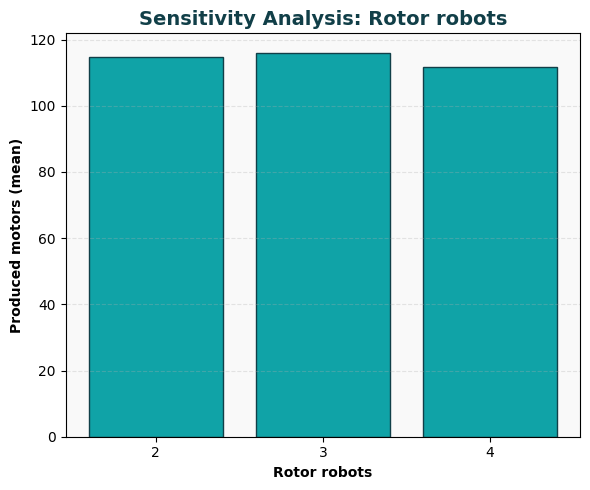

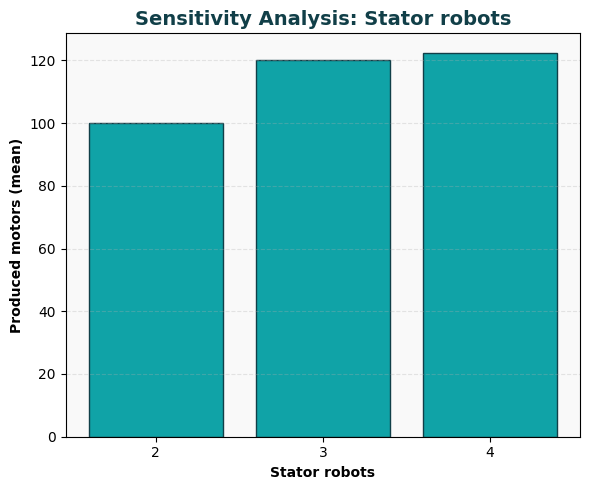

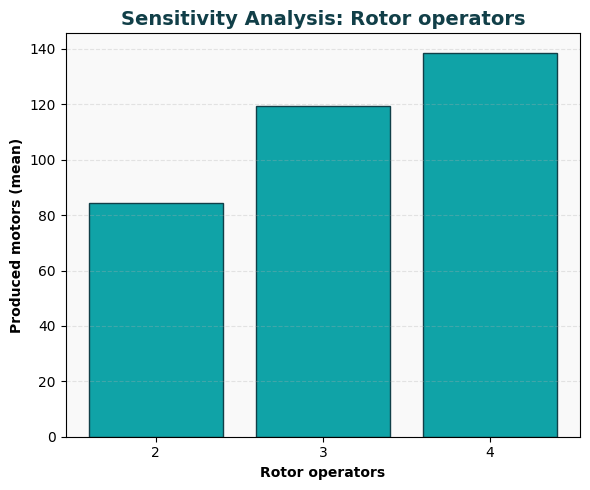

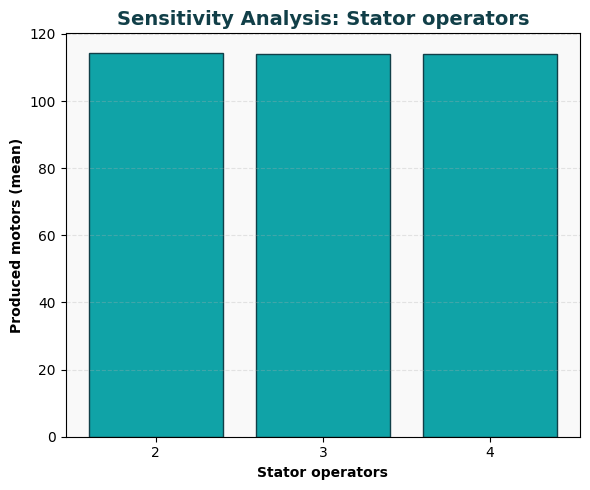

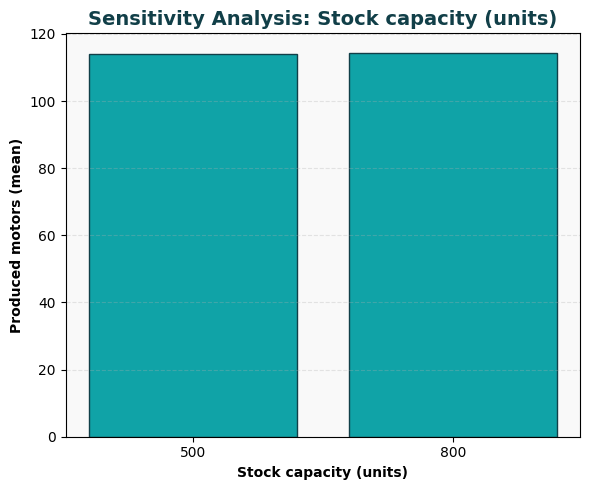

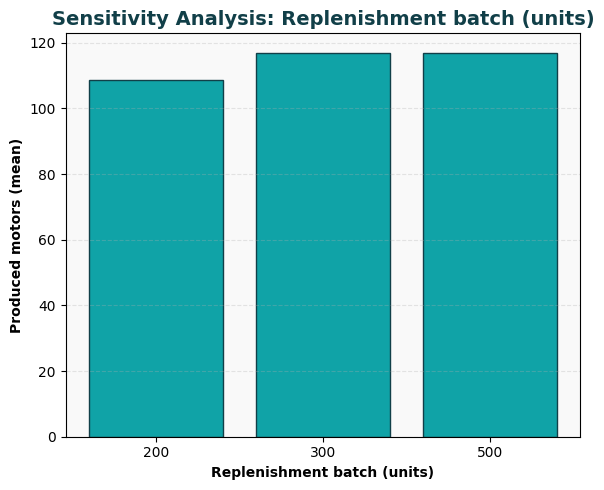

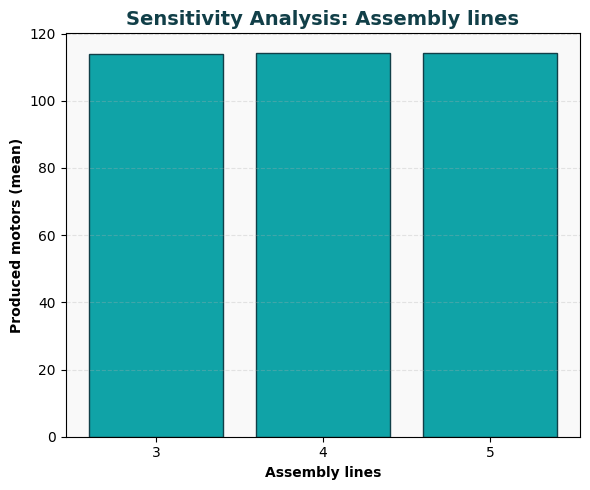

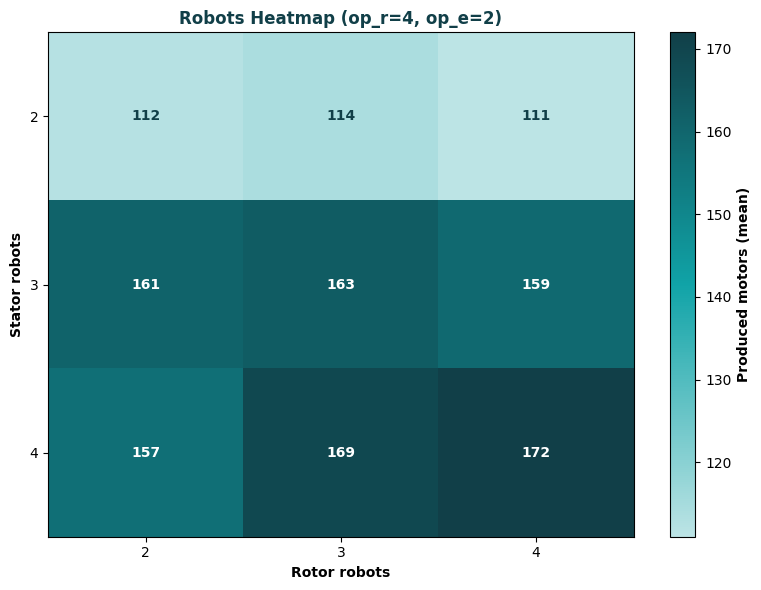

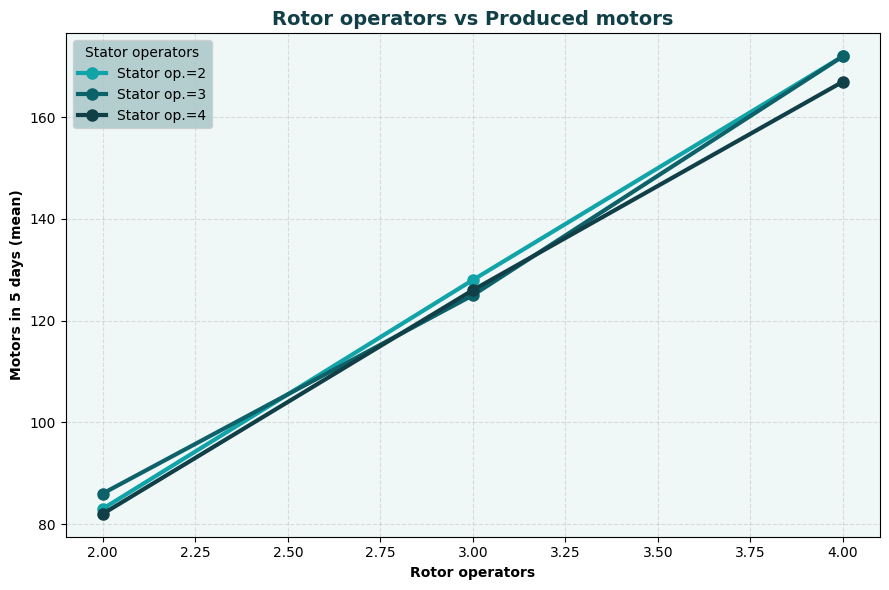

In [ ]:

paleta = ["#113f48", "#0d626a", "#10a3a7", "#bce4e5", "#a6c4c5"]
custom_cmap = LinearSegmentedColormap.from_list("custom_teal", [paleta[3], paleta[2], paleta[0]])


params_plot = [
    ("robots_rotor",      "Rotor robots"),
    ("robots_estator",    "Stator robots"),
    ("operarios_rotor",   "Rotor operators"),
    ("operarios_estator", "Stator operators"),
    ("cap_stock",         "Stock capacity (units)"),
    ("lote_reposicion",   "Replenishment batch (units)"),
    ("lineas_ensamblado", "Assembly lines"),
]

for col, label in params_plot:
    
    g = df_grid.groupby(col)["motores_media"].mean().reset_index()
    
    fig, ax = plt.subplots(figsize=(6, 5))
    
    ax.bar(g[col].astype(str), g["motores_media"], 
           color=paleta[2], edgecolor=paleta[0], linewidth=1)
    
    ax.set_title(f"Sensitivity Analysis: {label}", fontweight="bold", color=paleta[0], fontsize=14)
    ax.set_xlabel(label, fontweight="bold")
    ax.set_ylabel("Produced motors (mean)", fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.set_facecolor("#f9f9f9")
    
    plt.tight_layout()
    plt.show()


mask = ((df_grid.cap_stock == int(mejor.cap_stock)) &
        (df_grid.lote_reposicion == int(mejor.lote_reposicion)) &
        (df_grid.lineas_ensamblado == int(mejor.lineas_ensamblado)) &
        (df_grid.operarios_rotor == int(mejor.operarios_rotor)) &
        (df_grid.operarios_estator == int(mejor.operarios_estator)))

pivot = df_grid[mask].pivot_table(index="robots_estator", 
                                  columns="robots_rotor", 
                                  values="motores_media")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot.values, cmap=custom_cmap, aspect="auto")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Produced motors (mean)", fontweight="bold")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"{v}" for v in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"{v}" for v in pivot.index])

ax.set_xlabel("Rotor robots", fontweight="bold")
ax.set_ylabel("Stator robots", fontweight="bold")
ax.set_title(f"Robots Heatmap (op_r={int(mejor.operarios_rotor)}, op_e={int(mejor.operarios_estator)})", 
             fontweight="bold", color=paleta[0])

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i,j]
        color_text = "white" if val > pivot.values.mean() else paleta[0]
        ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontweight="bold", color=color_text)

plt.tight_layout()
plt.show()


mask2 = ((df_grid.robots_rotor == int(mejor.robots_rotor)) &
         (df_grid.robots_estator == int(mejor.robots_estator)) &
         (df_grid.cap_stock == int(mejor.cap_stock)) &
         (df_grid.lote_reposicion == int(mejor.lote_reposicion)) &
         (df_grid.lineas_ensamblado == int(mejor.lineas_ensamblado)))

sub = df_grid[mask2].sort_values("operarios_rotor")
fig, ax = plt.subplots(figsize=(9, 6))


line_colors = [paleta[2], paleta[1], paleta[0]]

for (oe, g), color in zip(sub.groupby("operarios_estator"), line_colors):
    g = g.sort_values("operarios_rotor")
    ax.plot(g["operarios_rotor"], g["motores_media"], marker="o", linewidth=3, 
            label=f"Stator op.={oe}", color=color, markersize=8)

ax.set_title("Rotor operators vs Produced motors", fontweight="bold", fontsize=14, color=paleta[0])
ax.set_xlabel("Rotor operators", fontweight="bold")
ax.set_ylabel("Motors in 5 days (mean)", fontweight="bold")
ax.legend(title="Stator operators", frameon=True, facecolor=paleta[4])
ax.grid(linestyle="--", alpha=0.4)
ax.set_facecolor("#f0f7f7")

plt.tight_layout()
plt.show()

BASE CONFIGURATION
  punto_critico=250, lote=200
  Motors / 5 days: 84 +/- 5
  Stock wait:      0.0 min
  Rotor defects:   27.4%
  Stator defects:  2.0%

NEW CONFIGURATION (+1 stator robot, +1 rotor operator)
  punto_critico=265, lote=300
  Motors / 5 days: 125 +/- 6
  Stock wait:      0.2 min
  Rotor defects:   27.5%
  Stator defects:  2.2%

IMPROVEMENT: +41 motors (+48.7%)


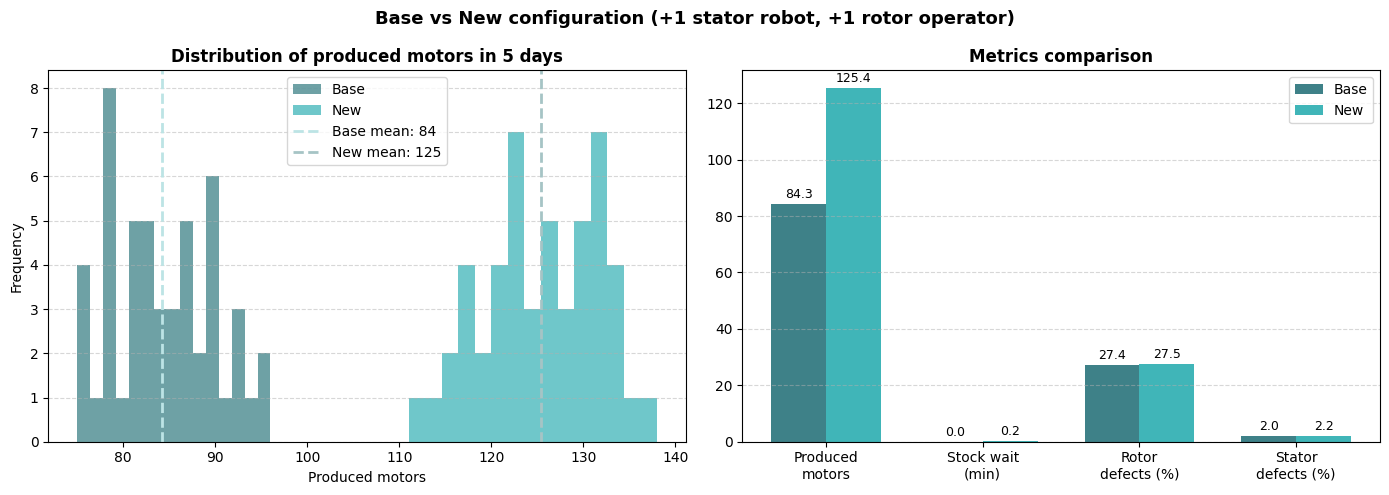

In [36]:
N_REPLICAS = 50

config_base  = dict(punto_critico=250, lote_reposicion=200)
config_nueva = dict(robots_estator=3, operarios_rotor=3, punto_critico=265, lote_reposicion=300)

replicas_base  = [ejecutar_simulacion(seed=i, **config_base)  for i in range(N_REPLICAS)]
replicas_nueva = [ejecutar_simulacion(seed=i, **config_nueva) for i in range(N_REPLICAS)]

motores_base  = [r["motores"] for r in replicas_base]
motores_nueva = [r["motores"] for r in replicas_nueva]

print("=" * 50)
print("BASE CONFIGURATION")
print(f"  punto_critico=250, lote=200")
print(f"  Motors / 5 days: {int(round(np.mean(motores_base)))} +/- {int(round(np.std(motores_base)))}")
print(f"  Stock wait:      {np.mean([r['espera'] for r in replicas_base]):.1f} min")
print(f"  Rotor defects:   {np.mean([r['pct_rot_def'] for r in replicas_base]):.1f}%")
print(f"  Stator defects:  {np.mean([r['pct_est_def'] for r in replicas_base]):.1f}%")
print()
print("NEW CONFIGURATION (+1 stator robot, +1 rotor operator)")
print(f"  punto_critico=265, lote=300")
print(f"  Motors / 5 days: {int(round(np.mean(motores_nueva)))} +/- {int(round(np.std(motores_nueva)))}")
print(f"  Stock wait:      {np.mean([r['espera'] for r in replicas_nueva]):.1f} min")
print(f"  Rotor defects:   {np.mean([r['pct_rot_def'] for r in replicas_nueva]):.1f}%")
print(f"  Stator defects:  {np.mean([r['pct_est_def'] for r in replicas_nueva]):.1f}%")

mejora     = int(round(np.mean(motores_nueva))) - int(round(np.mean(motores_base)))
mejora_pct = mejora / np.mean(motores_base) * 100
print()
print(f"IMPROVEMENT: +{mejora} motors (+{mejora_pct:.1f}%)")
print("=" * 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(motores_base,  bins=15, alpha=0.6, color="#0d626a", label="Base")
axes[0].hist(motores_nueva, bins=15, alpha=0.6, color="#10a3a7",  label="New")
axes[0].axvline(np.mean(motores_base),  color="#bce4e5", linestyle="--", linewidth=2,
                label=f"Base mean: {int(round(np.mean(motores_base)))}")
axes[0].axvline(np.mean(motores_nueva), color="#a6c4c5",  linestyle="--", linewidth=2,
                label=f"New mean: {int(round(np.mean(motores_nueva)))}")
axes[0].set_title("Distribution of produced motors in 5 days", fontweight="bold")
axes[0].set_xlabel("Produced motors")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

categorias = ["Produced\nmotors", "Stock wait\n(min)", "Rotor\ndefects (%)", "Stator\ndefects (%)"]
vals_base  = [
    np.mean(motores_base),
    np.mean([r["espera"]      for r in replicas_base]),
    np.mean([r["pct_rot_def"] for r in replicas_base]),
    np.mean([r["pct_est_def"] for r in replicas_base]),
]
vals_nueva = [
    np.mean(motores_nueva),
    np.mean([r["espera"]      for r in replicas_nueva]),
    np.mean([r["pct_rot_def"] for r in replicas_nueva]),
    np.mean([r["pct_est_def"] for r in replicas_nueva]),
]

x      = np.arange(len(categorias))
width  = 0.35
bars_b = axes[1].bar(x - width/2, vals_base,  width, label="Base",  color="#0d626a", alpha=0.8)
bars_n = axes[1].bar(x + width/2, vals_nueva, width, label="New", color="#10a3a7",  alpha=0.8)

for bar in bars_b:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9)
for bar in bars_n:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9)

axes[1].set_title("Metrics comparison", fontweight="bold")
axes[1].set_xticks(x)
axes[1].set_xticklabels(categorias)
axes[1].legend()
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Base vs New configuration (+1 stator robot, +1 rotor operator)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()